# Nara Hotéis — Tratamento de Dados
## Projeto Integrador | Análise de Dados

Este notebook realiza o processo completo de **identificação, discussão e correção das inconsistências** nas cinco bases de dados fornecidas pela Nara Hotéis.

Cada seção segue a mesma estrutura:
1. **Inspeção** — identificar os problemas
2. **Decisão** — discutir qual ação tomar e por quê
3. **Correção** — aplicar o tratamento com explicação linha a linha

---


## 0. Importações e Configurações

- **pandas** — manipulação de dados tabulares
- **numpy** — suporte a operações numéricas
- **re** — expressões regulares (usado na validação de e-mails e telefones)


In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)   # exibe todas as colunas
pd.set_option('display.max_colwidth', 60)    # não trunca o conteúdo
pd.set_option('display.float_format', '{:.2f}'.format)

print("Bibliotecas carregadas com sucesso.")


Bibliotecas carregadas com sucesso.


---
## 1. Carregamento das Bases

`pd.read_csv()` lê um arquivo CSV e transforma em um DataFrame — a estrutura de tabela do pandas.



In [2]:


hoteis   = pd.read_csv( 'hoteis.csv')
quartos  = pd.read_csv( 'quartos.csv')
hospedes = pd.read_csv( 'hospedes.csv')
reservas = pd.read_csv( 'reservas.csv')
avals    = pd.read_csv( 'avaliacoes.csv')

print("Bases carregadas!")
print(f"  hoteis:      {hoteis.shape}")
print(f"  quartos:     {quartos.shape}")
print(f"  hospedes:    {hospedes.shape}")
print(f"  reservas:    {reservas.shape}")
print(f"  avaliacoes:  {avals.shape}")


Bases carregadas!
  hoteis:      (5, 6)
  quartos:     (58, 7)
  hospedes:    (402, 8)
  reservas:    (1000, 10)
  avaliacoes:  (685, 8)


### Visão geral rápida

`isnull().sum()` conta os valores ausentes por coluna — boa forma de ter uma primeira leitura dos problemas.


In [3]:
# Nulos em cada base — chamadas individuais para cada DataFrame
print("--- hoteis ---")
print(hoteis.isnull().sum()[hoteis.isnull().sum() > 0].to_string() or "Sem nulos")
print()
print("--- quartos ---")
print(quartos.isnull().sum()[quartos.isnull().sum() > 0].to_string() or "Sem nulos")
print()
print("--- hospedes ---")
print(hospedes.isnull().sum()[hospedes.isnull().sum() > 0].to_string() or "Sem nulos")
print()
print("--- reservas ---")
print(reservas.isnull().sum()[reservas.isnull().sum() > 0].to_string() or "Sem nulos")
print()
print("--- avaliacoes ---")
print(avals.isnull().sum()[avals.isnull().sum() > 0].to_string() or "Sem nulos")


--- hoteis ---
n_quartos    1

--- quartos ---
valor_base    4

--- hospedes ---
cidade_origem    1
estado           1
genero           1

--- reservas ---
canal_reserva    5
valor_diaria     3

--- avaliacoes ---
nota_limpeza         4
nota_atendimento     2
comentario          53


---
## 2. hoteis.csv

Apenas 5 registros — um por unidade da rede. Apesar do volume pequeno, é a tabela de referência central: problemas aqui se propagam para todas as outras bases.


### 2.1 Inspeção

In [4]:
# Com apenas 5 linhas, visualizamos tudo de uma vez
print(hoteis.to_string())


   id_hotel           nome_hotel          cidade estado   categoria  n_quartos
0         1       Nara Fortaleza       Fortaleza     CE  5 estrelas     120.00
1         2          Nara Recife          Recife     PE  4 estrelas      95.00
2         3        Nara Salvador        Salvador     BA  4 estrelas        NaN
3         4  Nara Rio de Janeiro  Rio De Janeiro     RJ  3 estrelas      80.00
4         5       Nara São Paulo       Sao Paulo     SP  6 estrelas     150.00


In [5]:
# Valores únicos de categoria
print(hoteis['categoria'].value_counts())


categoria
4 estrelas    2
5 estrelas    1
3 estrelas    1
6 estrelas    1
Name: count, dtype: int64


### 2.2 Problemas e decisões

| # | Problema | Decisão |
|---|----------|---------|
| 1 | `'6 estrelas'` — fora do domínio (máximo é 5) | Corrigir → `'5 estrelas'` |
| 2 | `n_quartos` nulo em uma unidade | Corrigir → contar quartos cadastrados em `quartos.csv` |
| 3 | `'Rio De Janeiro'` com D maiúsculo | Padronizar → `str.title()` + ajuste manual |
| 4 | `'Sao Paulo'` sem acento | Padronizar → substituição direta |


### 2.3 Correção

**Categoria inválida**

`~isin()` seleciona os registros que **não estão** na lista de valores válidos. O `~` é o operador de negação — inverte True/False de cada linha.


In [6]:
dominios_validos = ['3 estrelas', '4 estrelas', '5 estrelas']

# Identificar registros fora do domínio
print("Categorias inválidas:")
print(hoteis.loc[~hoteis['categoria'].isin(dominios_validos), ['id_hotel', 'nome_hotel', 'categoria']])

# Corrigir
hoteis.loc[~hoteis['categoria'].isin(dominios_validos), 'categoria'] = '5 estrelas'
print("\nCategorias após correção:")
print(hoteis['categoria'].value_counts())


Categorias inválidas:
   id_hotel      nome_hotel   categoria
4         5  Nara São Paulo  6 estrelas

Categorias após correção:
categoria
5 estrelas    2
4 estrelas    2
3 estrelas    1
Name: count, dtype: int64


**`n_quartos` nulo**

Contamos quantos quartos cada hotel tem em `quartos.csv` e usamos esse valor para preencher o nulo. O `merge()` faz o cruzamento entre as duas bases pelo `id_hotel` — equivalente a um JOIN do SQL.


In [7]:
# Contar quartos por hotel em quartos.csv
quartos_por_hotel = (
    quartos
    .groupby('id_hotel')['id_quarto']   # agrupa por hotel e seleciona a coluna id_quarto
    .count()                            # conta quantos quartos cada hotel tem
    .reset_index()                      # transforma o índice em coluna
    .rename(columns={'id_quarto': 'n_quartos'})
)
print(quartos_por_hotel)


   id_hotel  n_quartos
0         1         12
1         2         11
2         3         11
3         4         10
4         5         13
5         9          1


In [8]:
# Cruzar com hoteis para preencher o nulo

# Remover a coluna auxiliar que usamos só para o preenchimento
hoteis = hoteis.drop(columns=['n_quartos'])

# merge() une as duas bases pelo id_hotel
hoteis = hoteis.merge(quartos_por_hotel, on='id_hotel', how='left')




print(hoteis[['id_hotel', 'nome_hotel', 'n_quartos']])


   id_hotel           nome_hotel  n_quartos
0         1       Nara Fortaleza         12
1         2          Nara Recife         11
2         3        Nara Salvador         11
3         4  Nara Rio de Janeiro         10
4         5       Nara São Paulo         13


**Cidades com grafia inconsistente**

`str.title()` capitaliza a primeira letra de cada palavra. Depois usamos `replace()` para corrigir casos que o `title()` não resolve sozinho — como acentos e preposições.


In [9]:
hoteis['cidade'] = (
    hoteis['cidade']
    .str.strip()      # remove espaços nas bordas
    .str.title()      # capitaliza a primeira letra de cada palavra
    .replace({
        'Sao Paulo':      'São Paulo',       # acento ausente
        'Rio De Janeiro': 'Rio de Janeiro',  # preposição 'de' em minúsculo
    })
)

print(hoteis[['id_hotel', 'nome_hotel', 'cidade', 'estado']])


   id_hotel           nome_hotel          cidade estado
0         1       Nara Fortaleza       Fortaleza     CE
1         2          Nara Recife          Recife     PE
2         3        Nara Salvador        Salvador     BA
3         4  Nara Rio de Janeiro  Rio de Janeiro     RJ
4         5       Nara São Paulo       São Paulo     SP


In [10]:
print("hoteis — situação final:")
print(f"  Linhas: {len(hoteis)}")
print(hoteis.isnull().sum())


hoteis — situação final:
  Linhas: 5
id_hotel      0
nome_hotel    0
cidade        0
estado        0
categoria     0
n_quartos     0
dtype: int64


---
## 3. quartos.csv

Catálogo de quartos de cada hotel. A capacidade total de cada unidade é calculada a partir daqui — essencial para a análise de overbooking.


### 3.1 Inspeção

In [11]:
print(quartos.dtypes)
print()
print("Nulos por coluna:")
print(quartos.isnull().sum())


id_quarto          str
id_hotel         int64
tipo_quarto        str
capacidade       int64
valor_base     float64
andar            int64
vista              str
dtype: object

Nulos por coluna:
id_quarto      0
id_hotel       0
tipo_quarto    0
capacidade     0
valor_base     4
andar          0
vista          0
dtype: int64


In [12]:
# Grafias em tipo_quarto
print("Valores únicos em tipo_quarto:")
print(quartos['tipo_quarto'].value_counts())


Valores únicos em tipo_quarto:
tipo_quarto
Standard        12
Luxo            11
Superior        10
Suite            9
Suite Master     5
Standart         2
STANDARD         2
superior         2
standard         2
SUPERIOR         2
STANDART         1
Name: count, dtype: int64


In [13]:
# Capacidades inválidas
print("Capacidades <= 0:")
print(quartos.loc[quartos['capacidade'] <= 0, ['id_quarto', 'id_hotel', 'tipo_quarto', 'capacidade']])


Capacidades <= 0:
   id_quarto  id_hotel tipo_quarto  capacidade
9       Q010         1       Suite           0
10      Q011         1       Suite          -1
53      Q054         5        Luxo          -2


In [14]:
# Quarto com id_hotel inexistente
ids_hoteis_validos = hoteis['id_hotel'].tolist()
print("Quartos com id_hotel sem correspondência em hoteis.csv:")
print(quartos.loc[~quartos['id_hotel'].isin(ids_hoteis_validos), ['id_quarto', 'id_hotel', 'tipo_quarto']])


Quartos com id_hotel sem correspondência em hoteis.csv:
   id_quarto  id_hotel tipo_quarto
57      Q058         9    Standard


### 3.2 Problemas e decisões

| # | Problema | Decisão |
|---|----------|---------|
| 1 | Grafias variadas: `'Standard'`, `'STANDARD'`, `'Standart'` | Padronizar → minúsculo + dicionário de correção + `title()` |
| 2 | Capacidade = 0 | Corrigir → mediana do mesmo tipo de quarto |
| 3 | Capacidade negativa | Remover |
| 4 | `valor_base` nulo | Corrigir → mediana do mesmo tipo no mesmo hotel |
| 5 | `id_hotel = 9` inexistente | Remover |

> **Por que mediana e não média?** A mediana ignora valores extremos. Se há suítes com preços muito altos, a média seria distorcida — a mediana é mais representativa para quartos simples.


### 3.3 Correção

In [15]:
# Padronizar tipo_quarto em 3 passos encadeados
correcoes_tipo = {'standart': 'standard'}  # erros de digitação conhecidos

quartos['tipo_quarto'] = (
    quartos['tipo_quarto']
    .str.strip()               # remove espaços
    .str.lower()               # tudo minúsculo → elimina diferenças de caixa
    .replace(correcoes_tipo)   # corrige erros de digitação
    .str.title()               # capitalização padrão
)

print("Tipos após padronização:")
print(quartos['tipo_quarto'].value_counts())


Tipos após padronização:
tipo_quarto
Standard        19
Superior        14
Luxo            11
Suite            9
Suite Master     5
Name: count, dtype: int64


**Capacidade zerada**

`transform('median')` calcula a mediana dentro de cada grupo e devolve o resultado no mesmo índice do DataFrame original — sem precisar de merge ou loop.


In [16]:
# Calcular a mediana de capacidade por tipo de quarto (só dos válidos)
mediana_cap = (
    quartos[quartos['capacidade'] > 0]          # usa só registros válidos no cálculo
    .groupby('tipo_quarto')['capacidade']
    .transform('median')                        # devolve o valor no índice original
)

# Onde capacidade é 0, substituir pela mediana do tipo
mask_zero = quartos['capacidade'] == 0
quartos.loc[mask_zero, 'capacidade'] = mediana_cap[mask_zero]

print(f"Registros corrigidos (capacidade 0): {mask_zero.sum()}")


Registros corrigidos (capacidade 0): 1


In [17]:
# Remover capacidades negativas
antes = len(quartos)
quartos = quartos[quartos['capacidade'] > 0].copy()
print(f"Removidos (capacidade negativa): {antes - len(quartos)}")


Removidos (capacidade negativa): 3


**`valor_base` nulo**

`groupby().transform('median')` é a mesma estratégia — calcula a mediana por grupo e preenche os nulos sem precisar de loop.


In [18]:
# Calcular mediana de valor_base por hotel + tipo de quarto
mediana_valor = (
    quartos
    .groupby(['id_hotel', 'tipo_quarto'])['valor_base']
    .transform('median')
)

# fillna() preenche só onde o valor é nulo
quartos['valor_base'] = quartos['valor_base'].fillna(mediana_valor)

print(f"Nulos restantes em valor_base: {quartos['valor_base'].isnull().sum()}")


Nulos restantes em valor_base: 0


In [19]:
# Remover quarto com id_hotel inexistente
antes = len(quartos)
quartos = quartos[quartos['id_hotel'].isin(ids_hoteis_validos)].copy()
print(f"Removidos (id_hotel inválido): {antes - len(quartos)}")


Removidos (id_hotel inválido): 1


In [20]:
print("quartos — situação final:")
print(f"  Linhas: {len(quartos)}")
print(quartos.isnull().sum())


quartos — situação final:
  Linhas: 54
id_quarto      0
id_hotel       0
tipo_quarto    0
capacidade     0
valor_base     0
andar          0
vista          0
dtype: int64


---
## 4. hospedes.csv

Base com maior variedade de inconsistências — campos textuais, datas e identificadores todos com problemas.


### 4.1 Inspeção

In [21]:
print(hospedes.dtypes)
print()
print("Nulos por coluna:")
print(hospedes.isnull().sum())


id_hospede         int64
nome                 str
email                str
telefone             str
cidade_origem        str
estado               str
data_nascimento      str
genero               str
dtype: object

Nulos por coluna:
id_hospede         0
nome               0
email              0
telefone           0
cidade_origem      1
estado             1
data_nascimento    0
genero             1
dtype: int64


In [22]:
# E-mails sem '@'
print("E-mails sem '@':")
print(hospedes.loc[~hospedes['email'].str.contains('@', na=False), ['id_hospede', 'nome', 'email']])


E-mails sem '@':
    id_hospede               nome                   email
4            5  Cristina Ferreira  carlossilva.semdominio
11          12       Daniel Souza   emailsemarrobasemnada


In [23]:
# IDs duplicados
# duplicated(keep=False) marca TODOS os duplicados, inclusive o primeiro
print("IDs duplicados:")
print(hospedes.loc[hospedes.duplicated('id_hospede', keep=False), ['id_hospede', 'nome', 'email']])


IDs duplicados:
     id_hospede           nome                        email
49           50  Rodrigo Alves   rodrigo.alves3@hotmail.com
99          100  Bruno Pereira  bruno.pereira61@outlook.com
400          50  Rodrigo Alves   rodrigo.alves3@hotmail.com
401         100  Bruno Pereira  bruno.pereira61@outlook.com


In [24]:
print("Valores únicos em 'estado':")
print(hospedes['estado'].value_counts(dropna=False))


Valores únicos em 'estado':
estado
MG                44
DF                43
AM                42
SP                41
RS                41
PR                40
CE                37
PE                37
BA                37
RJ                36
rio de janeiro     1
NaN                1
Sp                 1
RRJ                1
Name: count, dtype: int64


In [25]:
print("Valores únicos em 'genero':")
print(hospedes['genero'].value_counts(dropna=False))


Valores únicos em 'genero':
genero
F            200
M            199
Masculino      1
fem            1
NaN            1
Name: count, dtype: int64


In [26]:
# Datas de nascimento: converter e verificar limites
hospedes['data_nascimento'] = pd.to_datetime(hospedes['data_nascimento'], errors='coerce')

limite_inf = pd.Timestamp('1920-01-01')
limite_sup = pd.Timestamp('2007-01-01')

mask_data_inv = (
    hospedes['data_nascimento'].notna() &
    ((hospedes['data_nascimento'] < limite_inf) | (hospedes['data_nascimento'] > limite_sup))
)
print(f"Datas suspeitas: {mask_data_inv.sum()}")
print(hospedes.loc[mask_data_inv, ['id_hospede', 'nome', 'data_nascimento']])


Datas suspeitas: 2
    id_hospede              nome data_nascimento
19          20     Leonardo Dias      1899-03-15
54          55  Carolina Ribeiro      2020-06-10


### 4.2 Problemas e decisões

| # | Problema | Decisão |
|---|----------|---------|
| 1 | E-mails inválidos (sem `@`, `@@`, sem domínio) | Invalidar → nulo |
| 2 | Telefones com formatos variados | Padronizar → só dígitos; incompletos → nulo |
| 3 | Nomes com caixa inconsistente e espaços | Padronizar → `strip()` + `title()` |
| 4 | Siglas de estado inválidas ou por extenso | Padronizar → dicionário de mapeamento |
| 5 | Datas de nascimento impossíveis | Invalidar → nulo |
| 6 | Gênero com grafias variadas | Padronizar → `'M'` e `'F'` |
| 7 | IDs duplicados | Remover → manter primeiro registro |


### 4.3 Correção

**E-mails inválidos**

`str.contains()` verifica se a string contém um padrão. Usamos uma expressão regular simples para checar o formato mínimo de e-mail: `algo@algo.algo`.

- `na=False` trata os nulos como False sem gerar erro
- `~` inverte a condição: seleciona os que **não** batem com o padrão


In [27]:
# Padrão mínimo de e-mail: algo@algo.algo
# ^ = início, $ = fim, [^@]+ = um ou mais caracteres que não sejam @
padrao_email = r'^[^@]+@[^@]+\.[^@]+$'

# str.contains() retorna True onde o padrão bate
email_valido = hospedes['email'].str.contains(padrao_email, na=False)

print(f"E-mails inválidos encontrados: {(~email_valido).sum()}")

# Onde o e-mail é inválido, substituir por nulo
hospedes.loc[~email_valido, 'email'] = None
print(f"Nulos em email após correção: {hospedes['email'].isnull().sum()}")


E-mails inválidos encontrados: 3
Nulos em email após correção: 3


**Telefones**

`str.replace()` com regex remove tudo que não for dígito. Depois verificamos o comprimento — telefones brasileiros têm 10 ou 11 dígitos. Fora disso, vira nulo.

- `\D` é o padrão para "qualquer caractere que não seja dígito"
- `regex=True` ativa a interpretação como expressão regular


In [28]:
# Remover tudo que não for dígito
hospedes['telefone'] = hospedes['telefone'].str.replace(r'\D', '', regex=True)

# Calcular o comprimento de cada telefone
tamanho = hospedes['telefone'].str.len()

# Marcar como nulo onde o comprimento não é 10 nem 11
hospedes.loc[~tamanho.isin([10, 11]), 'telefone'] = None

print(f"Telefones válidos: {hospedes['telefone'].notnull().sum()}")
print(f"Telefones nulos:   {hospedes['telefone'].isnull().sum()}")


Telefones válidos: 400
Telefones nulos:   2


**Nomes**

Duas operações em cadeia resolvem os problemas de caixa e espaços.


In [29]:
hospedes['nome'] = hospedes['nome'].str.strip().str.title()

print("Amostra após padronização:")
print(hospedes['nome'].head(8).to_string())


Amostra após padronização:
0       Carlos Pereira
1          Diego Alves
2        Bruno Ribeiro
3       Sandra Pereira
4    Cristina Ferreira
5     Mariana Carvalho
6          Amanda Dias
7        Paulo Martins


**Estados**

`map()` substitui cada valor pelo correspondente no dicionário. O que não estiver no dicionário vira `NaN`.

> Diferença entre `map()` e `replace()`: o `replace()` mantém o valor original se ele não estiver no dicionário. O `map()` substitui por `NaN`. Aqui queremos `NaN` para siglas desconhecidas — então usamos `map()`.


In [30]:
# Dicionário completo: variações → sigla oficial
mapa_estado = {
    # Siglas já corretas
    'AC': 'AC', 'AL': 'AL', 'AP': 'AP', 'AM': 'AM', 'BA': 'BA',
    'CE': 'CE', 'DF': 'DF', 'ES': 'ES', 'GO': 'GO', 'MA': 'MA',
    'MT': 'MT', 'MS': 'MS', 'MG': 'MG', 'PA': 'PA', 'PB': 'PB',
    'PR': 'PR', 'PE': 'PE', 'PI': 'PI', 'RJ': 'RJ', 'RN': 'RN',
    'RS': 'RS', 'RO': 'RO', 'RR': 'RR', 'SC': 'SC', 'SP': 'SP',
    'SE': 'SE', 'TO': 'TO',
    # Variações incorretas
    'rj': 'RJ', 'rio de janeiro': 'RJ',
    'sp': 'SP', 'sao paulo': 'SP', 'são paulo': 'SP',
    'mg': 'MG', 'ba': 'BA', 'ce': 'CE',
}

# Normalizar e mapear
# .str.lower() garante que bata com as chaves do dicionário (todas em minúsculo)
hospedes['estado'] = (
    hospedes['estado']
    .str.strip()
    .str.lower()
    .map(mapa_estado)   # o que não estiver no dicionário vira NaN
)

print("Estados após normalização:")
print(hospedes['estado'].value_counts(dropna=False))


Estados após normalização:
estado
NaN    205
MG      44
SP      42
RJ      37
CE      37
BA      37
Name: count, dtype: int64


In [31]:
# Datas inválidas → nulo
# mask_data_inv já foi calculada na inspeção
hospedes.loc[mask_data_inv, 'data_nascimento'] = None
print(f"Datas invalidadas: {mask_data_inv.sum()}")


Datas invalidadas: 2


In [32]:
# Gênero: map() com dicionário — o que não está vira NaN
mapa_genero = {
    'm': 'M', 'masculino': 'M', 'masc': 'M',
    'f': 'F', 'feminino':  'F', 'fem':  'F',
}

hospedes['genero'] = (
    hospedes['genero']
    .str.strip()
    .str.lower()
    .map(mapa_genero)
)

print("Gênero após padronização:")
print(hospedes['genero'].value_counts(dropna=False))


Gênero após padronização:
genero
F      201
M      200
NaN      1
Name: count, dtype: int64


In [33]:
# Remover IDs duplicados — manter primeira ocorrência
antes = len(hospedes)
hospedes = hospedes.drop_duplicates(subset='id_hospede', keep='first').copy()
print(f"Removidos (ID duplicado): {antes - len(hospedes)}")


Removidos (ID duplicado): 2


In [34]:
print("hospedes — situação final:")
print(f"  Linhas: {len(hospedes)}")
print(hospedes.isnull().sum())


hospedes — situação final:
  Linhas: 400
id_hospede           0
nome                 0
email                3
telefone             2
cidade_origem        1
estado             204
data_nascimento      3
genero               1
dtype: int64


---
## 5. reservas.csv

Tabela fato principal — fonte central de todas as análises de receita, volume e overbooking.


### 5.1 Inspeção

In [35]:
print(reservas.dtypes)
print()
print("Nulos por coluna:")
print(reservas.isnull().sum())


id_reserva          int64
id_hospede          int64
id_quarto             str
id_hotel            int64
data_checkin          str
data_checkout         str
canal_reserva         str
valor_diaria      float64
status_reserva        str
data_reserva          str
dtype: object

Nulos por coluna:
id_reserva        0
id_hospede        0
id_quarto         0
id_hotel          0
data_checkin      0
data_checkout     0
canal_reserva     5
valor_diaria      3
status_reserva    0
data_reserva      0
dtype: int64


In [36]:
# Converter colunas de data
# errors='coerce' transforma valores impossíveis em NaT em vez de levantar erro
reservas['data_checkin']  = pd.to_datetime(reservas['data_checkin'],  errors='coerce')
reservas['data_checkout'] = pd.to_datetime(reservas['data_checkout'], errors='coerce')
reservas['data_reserva']  = pd.to_datetime(reservas['data_reserva'],  errors='coerce')

# Checkout inválido
print(f"Checkout anterior ou igual ao checkin: {(reservas['data_checkout'] <= reservas['data_checkin']).sum()}")


Checkout anterior ou igual ao checkin: 5


In [37]:
# Estatísticas do valor da diária
print(reservas['valor_diaria'].describe())
print(f"\nValores negativos: {(reservas['valor_diaria'] < 0).sum()}")
print(f"Valores zero:      {(reservas['valor_diaria'] == 0).sum()}")
print(f"Valores nulos:     {reservas['valor_diaria'].isnull().sum()}")


count     997.00
mean     1615.29
std      1551.61
min      -274.84
25%       895.60
50%      1528.24
75%      2138.14
max     24637.28
Name: valor_diaria, dtype: float64

Valores negativos: 3
Valores zero:      1
Valores nulos:     3


In [38]:
print("Valores em status_reserva:")
print(reservas['status_reserva'].value_counts(dropna=False))


Valores em status_reserva:
status_reserva
Confirmada     965
Overbooking     18
Cancelado        7
No-show          4
no-show          2
CONFIRMADA       2
confirmada       1
Cancelada        1
Name: count, dtype: int64


In [39]:
print("Valores em canal_reserva:")
print(reservas['canal_reserva'].value_counts(dropna=False))


Valores em canal_reserva:
canal_reserva
Expedia              220
Booking.com          205
Site Próprio         203
Telefone             179
Agência de Viagem    176
EXPEDIA                5
NaN                    5
site próprio           3
Agencia de Viagem      2
booking.com            2
Name: count, dtype: int64


In [40]:
# id_hospede sem correspondência
ids_hospedes_validos = hospedes['id_hospede'].tolist()
print(f"Reservas com id_hospede inválido: {(~reservas['id_hospede'].isin(ids_hospedes_validos)).sum()}")

# data_reserva posterior ao checkin
print(f"data_reserva posterior ao checkin: {(reservas['data_reserva'] > reservas['data_checkin']).sum()}")


Reservas com id_hospede inválido: 5
data_reserva posterior ao checkin: 4


### 5.2 Problemas e decisões

| # | Problema | Decisão |
|---|----------|---------|
| 1 | Checkout anterior/igual ao checkin | Remover |
| 2 | Diária negativa, zero ou nula | Remover |
| 3 | Status com grafias mistas | Padronizar |
| 4 | Canal com grafias mistas | Padronizar |
| 5 | Canal nulo | Preencher com `'Não informado'` |
| 6 | `id_hospede` inexistente | Remover |
| 7 | `data_reserva` posterior ao checkin | Remover |

> **Sobre outliers de valor_diaria:** valores extremamente altos são mantidos aqui — serão analisados na etapa de estatística com IQR.


### 5.3 Correção

In [41]:
# 1. Checkout inválido
antes = len(reservas)
reservas = reservas[reservas['data_checkout'] > reservas['data_checkin']].copy()
print(f"Removidos (checkout inválido): {antes - len(reservas)}")


Removidos (checkout inválido): 5


In [42]:
# 2. Diárias inválidas — negativas, zero e nulas em uma só etapa
antes = len(reservas)
reservas = reservas[reservas['valor_diaria'].notna() & (reservas['valor_diaria'] > 0)].copy()
print(f"Removidos (diária inválida): {antes - len(reservas)}")


Removidos (diária inválida): 7


In [43]:
# 3. Padronizar status_reserva com map()
mapa_status = {
    'confirmada':  'Confirmada',  'Confirmada': 'Confirmada', 'CONFIRMADA': 'Confirmada',
    'cancelada':   'Cancelada',   'Cancelada':  'Cancelada',  'Cancelado':  'Cancelada',
    'no-show':     'No-show',     'No-show':    'No-show',    'NO-SHOW':    'No-show',
    'overbooking': 'Overbooking', 'Overbooking':'Overbooking',
}
reservas['status_reserva'] = reservas['status_reserva'].map(mapa_status)

print("Status após padronização:")
print(reservas['status_reserva'].value_counts(dropna=False))


Status após padronização:
status_reserva
Confirmada     956
Overbooking     18
Cancelada        8
No-show          6
Name: count, dtype: int64


In [44]:
# 4. Padronizar canal_reserva
mapa_canal = {
    'Site Próprio': 'Site Próprio',  'site próprio':      'Site Próprio',
    'Booking.com':  'Booking.com',   'booking.com':       'Booking.com',
    'Expedia':      'Expedia',       'EXPEDIA':            'Expedia',
    'Agência de Viagem': 'Agência de Viagem',
    'Agencia de Viagem': 'Agência de Viagem',
    'Telefone':     'Telefone',
}
reservas['canal_reserva'] = reservas['canal_reserva'].map(mapa_canal)

# 5. Canal nulo → 'Não informado'
reservas['canal_reserva'] = reservas['canal_reserva'].fillna('Não informado')

print("Canal após padronização:")
print(reservas['canal_reserva'].value_counts(dropna=False))


Canal após padronização:
canal_reserva
Expedia              224
Site Próprio         204
Booking.com          202
Telefone             177
Agência de Viagem    176
Não informado          5
Name: count, dtype: int64


In [45]:
# 6. Remover id_hospede inexistente
antes = len(reservas)
reservas = reservas[reservas['id_hospede'].isin(ids_hospedes_validos)].copy()
print(f"Removidos (id_hospede inválido): {antes - len(reservas)}")


Removidos (id_hospede inválido): 5


In [46]:
# 7. Remover data_reserva posterior ao checkin
antes = len(reservas)
reservas = reservas[reservas['data_reserva'] <= reservas['data_checkin']].copy()
print(f"Removidos (data_reserva inválida): {antes - len(reservas)}")


Removidos (data_reserva inválida): 4


In [47]:
print("reservas — situação final:")
print(f"  Linhas: {len(reservas)}")
print()
print(reservas.isnull().sum())
print()
print(reservas['status_reserva'].value_counts())


reservas — situação final:
  Linhas: 979

id_reserva        0
id_hospede        0
id_quarto         0
id_hotel          0
data_checkin      0
data_checkout     0
canal_reserva     0
valor_diaria      0
status_reserva    0
data_reserva      0
dtype: int64

status_reserva
Confirmada     947
Overbooking     18
Cancelada        8
No-show          6
Name: count, dtype: int64


---
## 6. avaliacoes.csv

Notas e comentários dos hóspedes após a estadia. Os problemas principais envolvem o domínio das notas e a coerência com as reservas correspondentes.


### 6.1 Inspeção

In [48]:
print(avals.dtypes)
print()
print("Nulos por coluna:")
print(avals.isnull().sum())


id_avaliacao              int64
id_reserva                int64
nota_geral                  str
nota_limpeza            float64
nota_atendimento        float64
nota_custo_beneficio        str
comentario                  str
data_avaliacao              str
dtype: object

Nulos por coluna:
id_avaliacao             0
id_reserva               0
nota_geral               0
nota_limpeza             4
nota_atendimento         2
nota_custo_beneficio     0
comentario              53
data_avaliacao           0
dtype: int64


As colunas de nota podem ter chegado como `object` (texto) se alguma célula contiver um valor como `'ótimo'` ou `'9,0'`. O pandas lê a coluna inteira como texto ao encontrar qualquer valor não numérico.

`pd.to_numeric(errors='coerce')` tenta converter cada valor para número — o que não conseguir vira `NaN`.


In [49]:
# Converter colunas de nota para numérico
# errors='coerce' transforma valores como 'ótimo' ou '9,0' em NaN
avals['nota_geral']            = pd.to_numeric(avals['nota_geral'],            errors='coerce')
avals['nota_limpeza']          = pd.to_numeric(avals['nota_limpeza'],          errors='coerce')
avals['nota_atendimento']      = pd.to_numeric(avals['nota_atendimento'],      errors='coerce')
avals['nota_custo_beneficio']  = pd.to_numeric(avals['nota_custo_beneficio'],  errors='coerce')

print("Tipos após conversão:")
print(avals[['nota_geral','nota_limpeza','nota_atendimento','nota_custo_beneficio']].dtypes)


Tipos após conversão:
nota_geral              float64
nota_limpeza            float64
nota_atendimento        float64
nota_custo_beneficio    float64
dtype: object


In [50]:
# Notas fora do range 0–10
# between(0, 10) retorna True para valores dentro do intervalo
fora_geral   = avals['nota_geral'].notna()           & ~avals['nota_geral'].between(0, 10)
fora_limp    = avals['nota_limpeza'].notna()          & ~avals['nota_limpeza'].between(0, 10)
fora_atend   = avals['nota_atendimento'].notna()      & ~avals['nota_atendimento'].between(0, 10)
fora_cb      = avals['nota_custo_beneficio'].notna()  & ~avals['nota_custo_beneficio'].between(0, 10)

print(f"nota_geral fora do range:           {fora_geral.sum()}")
print(f"nota_limpeza fora do range:         {fora_limp.sum()}")
print(f"nota_atendimento fora do range:     {fora_atend.sum()}")
print(f"nota_custo_beneficio fora do range: {fora_cb.sum()}")


nota_geral fora do range:           3
nota_limpeza fora do range:         4
nota_atendimento fora do range:     3
nota_custo_beneficio fora do range: 0


In [51]:
# Converter data_avaliacao
avals['data_avaliacao'] = pd.to_datetime(avals['data_avaliacao'], errors='coerce')

# Cruzar com reservas para verificar coerência de datas e status
# merge() com how='left' mantém todas as linhas de avals
avals_check = avals.merge(
    reservas[['id_reserva', 'data_checkout', 'status_reserva']],
    on='id_reserva',
    how='left'
)

print(f"Avaliações com data anterior ao checkout: {(avals_check['data_avaliacao'] < avals_check['data_checkout']).sum()}")
print(f"Avaliações de reservas canceladas/no-show: {avals_check['status_reserva'].isin(['Cancelada','No-show']).sum()}")


Avaliações com data anterior ao checkout: 4
Avaliações de reservas canceladas/no-show: 8


### 6.2 Problemas e decisões

| # | Problema | Decisão |
|---|----------|---------|
| 1 | Notas fora do range 0–10 em `nota_geral` | Remover o registro |
| 2 | Notas fora do range em campos secundários | Invalidar só o campo → nulo |
| 3 | Data de avaliação anterior ao checkout | Remover |
| 4 | Avaliações de reservas canceladas/no-show | Remover |
| 5 | Notas nulas em campos secundários | Manter — excluir só da análise daquele critério |

> **Por que remover o registro quando `nota_geral` é inválida, mas só invalidar o campo quando é `nota_limpeza`?** A `nota_geral` é a métrica principal. Sem ela o registro perde sentido analítico. Campos secundários nulos ainda permitem análises parciais.


### 6.3 Correção

In [52]:
# Remover registros com nota_geral fora do domínio (inclui os que viraram NaN)
antes = len(avals)
avals = avals[avals['nota_geral'].notna() & avals['nota_geral'].between(0, 10)].copy()
print(f"Removidos (nota_geral inválida): {antes - len(avals)}")


Removidos (nota_geral inválida): 6


In [53]:
# Invalidar campos secundários com valor fora do range
# Substituímos só o campo — o registro permanece
fora_limp   = avals['nota_limpeza'].notna()         & ~avals['nota_limpeza'].between(0, 10)
fora_atend  = avals['nota_atendimento'].notna()     & ~avals['nota_atendimento'].between(0, 10)
fora_cb     = avals['nota_custo_beneficio'].notna() & ~avals['nota_custo_beneficio'].between(0, 10)

avals.loc[fora_limp,  'nota_limpeza']          = None
avals.loc[fora_atend, 'nota_atendimento']      = None
avals.loc[fora_cb,    'nota_custo_beneficio']  = None

print(f"nota_limpeza invalidadas:          {fora_limp.sum()}")
print(f"nota_atendimento invalidadas:      {fora_atend.sum()}")
print(f"nota_custo_beneficio invalidadas:  {fora_cb.sum()}")


nota_limpeza invalidadas:          4
nota_atendimento invalidadas:      3
nota_custo_beneficio invalidadas:  0


**Avaliações com data inválida e de reservas canceladas**

Usamos `merge()` para cruzar com a base de reservas e obter as informações necessárias para os dois filtros de uma vez.


In [54]:
# Cruzar avaliações com reservas para obter data_checkout e status
avals = avals.merge(
    reservas[['id_reserva', 'data_checkout', 'status_reserva']],
    on='id_reserva',
    how='left'
)

# Remover avaliações com data anterior ao checkout
antes = len(avals)
avals = avals[
    avals['data_avaliacao'].isna() |              # mantém os que não têm data (NaT)
    (avals['data_avaliacao'] >= avals['data_checkout'])  # ou que são posteriores ao checkout
].copy()
print(f"Removidos (avaliação antes do checkout): {antes - len(avals)}")


Removidos (avaliação antes do checkout): 19


In [55]:
# Remover avaliações de reservas canceladas ou no-show
antes = len(avals)
avals = avals[~avals['status_reserva'].isin(['Cancelada', 'No-show'])].copy()
print(f"Removidos (reserva cancelada/no-show): {antes - len(avals)}")

# Remover colunas auxiliares que vieram do merge
avals = avals.drop(columns=['data_checkout', 'status_reserva'])


Removidos (reserva cancelada/no-show): 8


In [56]:
print("avaliacoes — situação final:")
print(f"  Linhas: {len(avals)}")
print()
print(avals.isnull().sum())


avaliacoes — situação final:
  Linhas: 652

id_avaliacao             0
id_reserva               0
nota_geral               0
nota_limpeza             8
nota_atendimento         5
nota_custo_beneficio     2
comentario              52
data_avaliacao           0
dtype: int64


---
## 7. Consolidação Final

Resumo do processo e exportação das bases tratadas.


In [57]:
# Resumo comparativo
print(f"{'BASE':<22} {'ORIGINAL':>10} {'TRATADO':>10} {'REMOVIDOS':>12}")
print("-" * 56)
print(f"{'hoteis.csv':<22}       {5:>5}    {len(hoteis):>5}    {5 - len(hoteis):>5}")
print(f"{'quartos.csv':<22}      {58:>5}    {len(quartos):>5}    {58 - len(quartos):>5}")
print(f"{'hospedes.csv':<22}    {402:>5}    {len(hospedes):>5}    {402 - len(hospedes):>5}")
print(f"{'reservas.csv':<22}   {1000:>5}    {len(reservas):>5}    {1000 - len(reservas):>5}")
print(f"{'avaliacoes.csv':<22}  {685:>5}    {len(avals):>5}    {685 - len(avals):>5}")


BASE                     ORIGINAL    TRATADO    REMOVIDOS
--------------------------------------------------------
hoteis.csv                       5        5        0
quartos.csv                    58       54        4
hospedes.csv                402      400        2
reservas.csv              1000      979       21
avaliacoes.csv            685      652       33


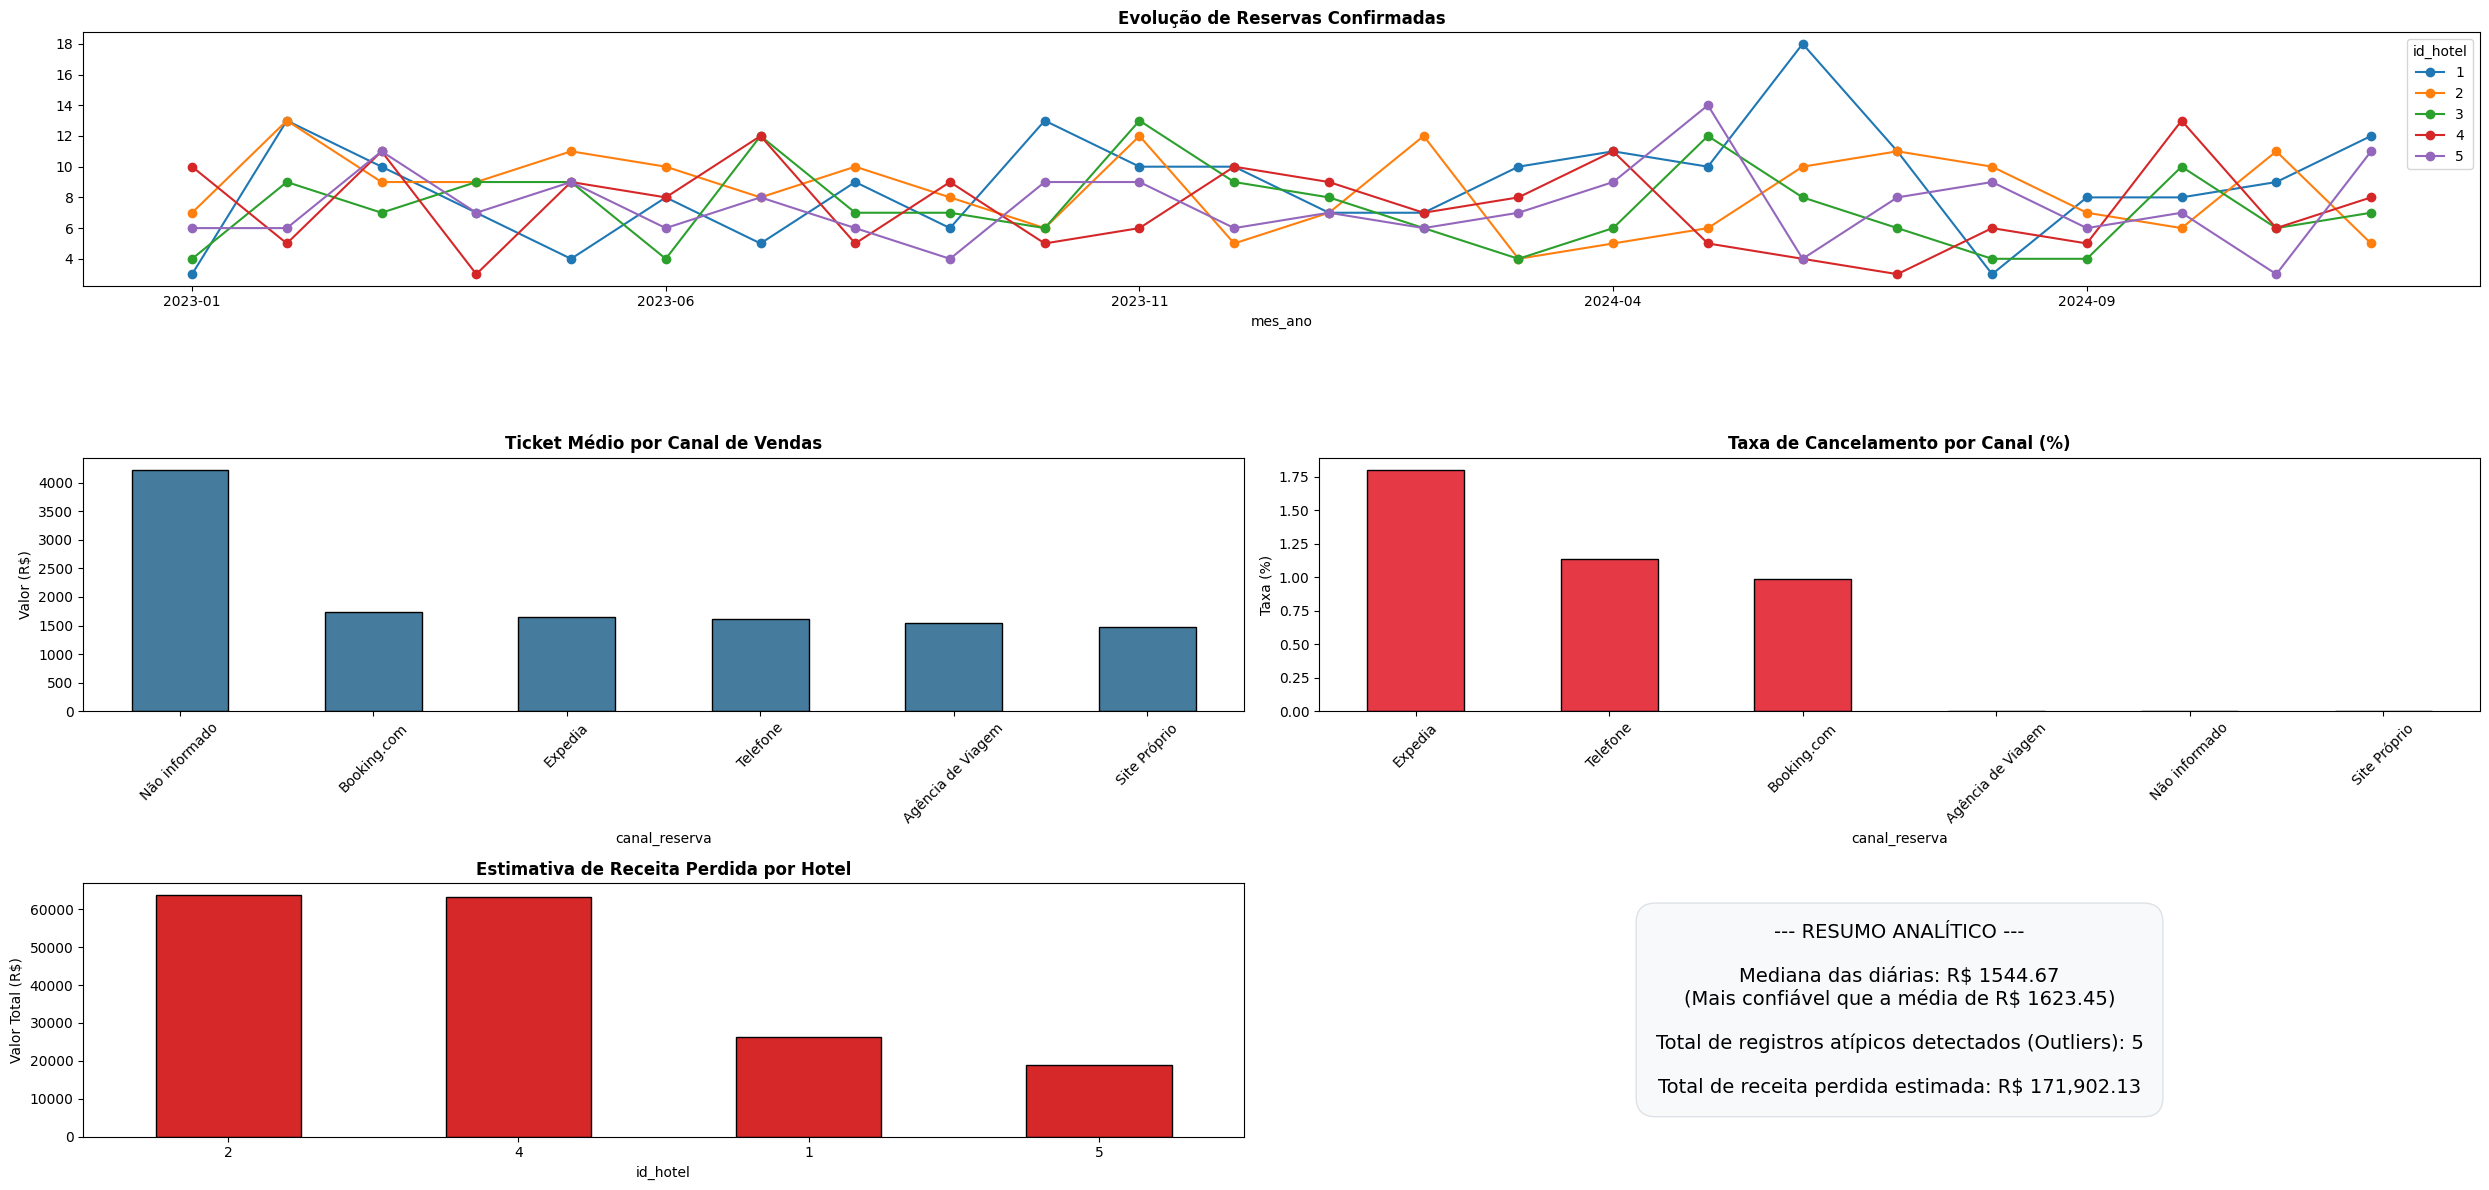

In [58]:
media_diaria = reservas['valor_diaria'].mean()
mediana_diaria = reservas['valor_diaria'].median()

Q1 = reservas['valor_diaria'].quantile(0.25)
Q3 = reservas['valor_diaria'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR
outliers_diaria = reservas[reservas['valor_diaria'] > limite_superior]

# 2. Volume Mensal de Reservas Confirmadas
df_confirmadas = reservas[reservas['status_reserva'] == 'Confirmada'].copy()
df_confirmadas['mes_ano'] = df_confirmadas['data_checkin'].dt.to_period('M').astype(str)
evolucao = df_confirmadas.groupby(['id_hotel', 'mes_ano']).size().reset_index(name='qtd')
pivot_evolucao = evolucao.pivot(index='mes_ano', columns='id_hotel', values='qtd').fillna(0)

# 3. Ticket Médio e Cancelamentos por Canal
ticket_medio = reservas.groupby('canal_reserva')['valor_diaria'].mean().sort_values(ascending=False)

total_canal = reservas.groupby('canal_reserva').size()
canceladas_canal = reservas[reservas['status_reserva'] == 'Cancelada'].groupby('canal_reserva').size()
taxa_cancelamento = (canceladas_canal / total_canal * 100).fillna(0).sort_values(ascending=False)

# 4. Impacto Financeiro (Receita Perdida por No-show/Cancelamento)
reservas['dias_estadia'] = (reservas['data_checkout'] - reservas['data_checkin']).dt.days
reservas['dias_estadia'] = reservas['dias_estadia'].replace(0, 1)
reservas['valor_total'] = reservas['valor_diaria'] * reservas['dias_estadia'].round(2)

df_perdas = reservas[reservas['status_reserva'].isin(['Cancelada', 'No-show'])]
receita_perdida = df_perdas.groupby('id_hotel')['valor_total'].sum().sort_values(ascending=False)


#(MATPLOTLIB)



fig = plt.figure(figsize=(25, 12))
gs = fig.add_gridspec(3, 2)

# Gráfico 1 ocupando a linha inteira
ax1 = fig.add_subplot(gs[0, :])
pivot_evolucao.plot(kind='line', marker='o', ax=ax1)
ax1.set_title('Evolução de Reservas Confirmadas', fontweight='bold')

# Gráfico 2
ax2 = fig.add_subplot(gs[1, 0])
ticket_medio.plot(kind='bar', color='#457b9d', edgecolor='black', ax=ax2)
ax2.set_title('Ticket Médio por Canal de Vendas', fontweight='bold')
ax2.set_ylabel('Valor (R$)')
ax2.tick_params(axis='x', rotation=45)

# Gráfico 3
ax3 = fig.add_subplot(gs[1, 1])
taxa_cancelamento.plot(kind='bar', color='#e63946', edgecolor='black', ax=ax3)
ax3.set_title('Taxa de Cancelamento por Canal (%)', fontweight='bold')
ax3.set_ylabel('Taxa (%)')
ax3.tick_params(axis='x', rotation=45)

# Gráfico 4
ax4 = fig.add_subplot(gs[2, 0])
receita_perdida.plot(kind='bar', color='#d62828', edgecolor='black', ax=ax4)
ax4.set_title('Estimativa de Receita Perdida por Hotel', fontweight='bold')
ax4.set_ylabel('Valor Total (R$)')
ax4.tick_params(axis='x', rotation=0)


# Gráfico 5 - Resumo Analítico (Texto)
ax5 = fig.add_subplot(gs[2,1])

# Remove os eixos (linhas e números) para deixar apenas o texto
ax5.axis('off') 

# Montando o texto com quebras de linha (\n)
texto_resumo = (
    "--- RESUMO ANALÍTICO ---\n\n"
    f"Mediana das diárias: R$ {mediana_diaria:.2f}\n"
    f"(Mais confiável que a média de R$ {media_diaria:.2f})\n\n"
    f"Total de registros atípicos detectados (Outliers): {len(outliers_diaria)}\n\n"
    f"Total de receita perdida estimada: R$ {receita_perdida.sum():,.2f}"
)

# Inserindo o texto no centro da área (0.5, 0.5)
ax5.text(0.5, 0.5, texto_resumo, 
         fontsize=14, 
         ha='center', # Alinhamento horizontal no centro
         va='center', # Alinhamento vertical no centro
         bbox=dict(boxstyle='round,pad=1', facecolor='#f8f9fa', edgecolor='#dee2e6')) # Cria uma "caixa" bonitinha ao redor

plt.tight_layout()
plt.show()

In [59]:
OUTPUT = './'

hoteis.to_csv(OUTPUT    + 'hoteis_tratado.csv',    index=False, encoding='utf-8')
quartos.to_csv(OUTPUT   + 'quartos_tratado.csv',   index=False, encoding='utf-8')
hospedes.to_csv(OUTPUT  + 'hospedes_tratado.csv',  index=False, encoding='utf-8')
reservas.to_csv(OUTPUT  + 'reservas_tratado.csv',  index=False, encoding='utf-8')
avals.to_csv(OUTPUT     + 'avaliacoes_tratado.csv',index=False, encoding='utf-8')

print("Bases tratadas salvas com sucesso!")
print("Próxima etapa: análise estatística e painel de visualização.")


Bases tratadas salvas com sucesso!
Próxima etapa: análise estatística e painel de visualização.
